# Run ABC on LG analogues

This notebook runs the `lg_analogues` pipeline and then applies simple rejection + kernel ABC.
All posterior summaries are conditional on the selection/cuts `S` used here.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

# Ensure we import from /scripts (not notebooks/lg_analogues.py)
repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root / "scripts"))
sys.path.insert(0, str(repo_root / "illustris_python"))

import lg_analogues as lg
from lg_abc import (
    build_pair_catalog,
    make_feature_matrix,
    make_theta_vector,
    abc_distance_diagonal,
    abc_rejection_mask,
    abc_kernel_weights,
    summarize_posterior,
    effective_sample_size,
)

print("lg_analogues:", lg.__file__)


lg_analogues: /home/dsp/Desktop/dsp_v2/dsp-cosmology/scripts/lg_analogues.py


## 1) Load simulation data and constants
We load only the fields needed for this analysis to keep memory usage lower.
`h` and `box_ckpch` are required for correct distance conversions and periodic pair finding.

In [2]:
# Data paths and fields
basePath = os.path.expanduser("~/dsp26/dsp-cosmology")
snap = 99

subhalo_fields = [
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMass",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
]

sub = il.groupcat.loadSubhalos(basePath, snap, fields=subhalo_fields)
header_consts = lg.load_header_constants(basePath, snap)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

print("Loaded subhalos:", sub["count"])
print("h:", h, "box_ckpch:", box_ckpch)


Loaded subhalos: 14485709
h: 0.6774 box_ckpch: 205000.0


## 2) Define the selection S
`S` is the upstream conditioning event for inference:
- central + largest satellite per FoF group
- stellar-mass window
- later distance and isolation cuts

All posterior statements from ABC are conditional on `S` (not unconditional cosmological priors).

In [3]:
selection_config = lg.SelectionConfig(
    h=h,
    box_ckpch=box_ckpch,
    mstar_min=2e10,
    mstar_max=5e11,
    r_min_kpc=500.0,
    r_max_kpc=1000.0,
    v_tot_max=300,
    vt_min=0,             
    vt_max=300,           
    vr_min=-400,           
    vr_max=0,
    density_radius_kpc=2000,
    intruder_factor=0.5,
    third_massive_factor=1.5
)

sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=basePath,
    snap=snap,
    selection_config=selection_config
)

print("Selected objects:", sample.keep_idx.size)


Selected objects: 45392


## 3) Build candidate pairs
We find pairs in a physically motivated separation window.
This defines the candidate set before environmental filtering.

In [4]:
pair_set = lg.find_pairs_periodic(sub=sub, sample=sample, selection_config=selection_config)

print("Pairs before filtering:", pair_set.i.size)
print(50*"-")
print("Same-host pairs:", int(np.sum(pair_set.same_host)))
print("Different-host pairs:", int(np.sum(~pair_set.same_host)))
print(50*"-")
print("Pairs with force ratio < 0.5:", int(np.sum(pair_set.force_ratio < 0.5)))
print("Pairs with force ratio >= 0.5:", int(np.sum(pair_set.force_ratio >= 0.5)))
print(50*"-")
print("Tidally dominant pairs:", int(np.sum(pair_set.is_tidally_dominant)))
print("Tidally subdominant pairs:", int(np.sum(~pair_set.is_tidally_dominant)))

Pairs before filtering: 2655
--------------------------------------------------
Same-host pairs: 2084
Different-host pairs: 571
--------------------------------------------------
Pairs with force ratio < 0.5: 454
Pairs with force ratio >= 0.5: 2201
--------------------------------------------------
Tidally dominant pairs: 911
Tidally subdominant pairs: 1744


## 4) Apply pipeline filters and inspect cutflow

In [ ]:
pipeline = lg.AnaloguePipeline(pair_set)

iso_mask_1 = lg.isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pairs=pipeline.pairs,
    sample=sample,
    selection_config=selection_config
)
pipeline.apply_filter(
    f"No third subhalo more massive than factor x={selection_config.third_massive_factor} in same FoF group",
    iso_mask_1
)

iso_mask_2 = lg.isolation_filter_no_massive_intruder_within_distance_x(
    sub=sub,
    pairs=pipeline.pairs,
    sample=sample,
    selection_config=selection_config
)
pipeline.apply_filter(
    f"No subhalos more massive than factor x={selection_config.intruder_factor} within r={selection_config.density_radius_kpc} kpc from COM",
    iso_mask_2
)

vel_mask = lg.filter_by_vel(
    sub=sub,
    pairs=pipeline.pairs,
    sample=sample,
    selection_config=selection_config
)
pipeline.apply_filter(
    ", ".join([
        f"vt in [{selection_config.vt_min}, {selection_config.vt_max}]",
        f"vr in [{selection_config.vr_min}, {selection_config.vr_max}]", 
        f"v_tot <= {selection_config.v_tot_max}"
    ]),
    vel_mask
)

pipeline.print_cutflow()
cutflow = pipeline.get_cutflow()
cutflow

initial: 2655 pairs remaining
No third subhalo more massive than factor x=1.5 in same FoF group: 2601 pairs remaining
No subhalos more massive than factor x=0.5 within r=2000 kpc from COM: 2600 pairs remaining
vt in [0, 300], vr in [-400, 0], v_tot <= 300: 1455 pairs remaining


[{'label': 'initial', 'before': 2655, 'after': 2655, 'frac_kept': 1.0},
 {'label': 'No third subhalo more massive than factor x=1.5 in same FoF group',
  'before': 2655,
  'after': 2601,
  'frac_kept': 0.9796610169491525},
 {'label': 'No subhalos more massive than factor x=0.5 within r=2000 kpc from COM',
  'before': 2601,
  'after': 2600,
  'frac_kept': 0.9996155324875048},
 {'label': 'vt in [0, 300], vr in [-400, 0], v_tot <= 300',
  'before': 2600,
  'after': 1455,
  'frac_kept': 0.5596153846153846}]

## 5) Prepare ABC inputs
- `X`: summary features used for distance matching
- `theta`: target parameter whose posterior we summarize (`log10(mdm_sum)` here)
- `x_obs`, `sigma`: notebook-configurable observational target and uncertainty scale

Two ABC variants are shown:
- Rejection ABC: keep closest fraction
- Kernel ABC: weight all samples by Gaussian kernel in distance

### What ABC is doing here
By the time we reach this section, we already have a table of **analogue pairs** from the simulation *after* our selection and filtering steps `S`.

Each analogue pair provides two kinds of quantities:

- **x (constraints / observables-like features)**: things we can compare to the real Local Group, such as:
  - separation `r_kpc`
  - relative velocities `v_r`, `v_t`
  - stellar masses (optional; can be included later)

- **θ (target / unknown we want a prior for)**: a quantity we want to infer for the real Local Group.
  In this notebook we start with a *proxy* target:
  - `theta = log10(mdm_sum)` where `mdm_sum = mdm_i + mdm_j`

ABC is the rule:

- Compute how close each analogue's `x_i` is to the observed target `x_obs`
- Use that closeness to decide how much that analogue contributes to the posterior for `θ`

This notebook shows two common ABC variants:

#### Rejection ABC (easiest mental model)
1. Compute a distance `d_i` between `x_i` and `x_obs`
2. Accept the closest analogues (either `d_i <= ε` or "closest 5%")
3. Treat the accepted `θ_i` values as samples from an approximation of `p(θ | x_obs, S)`

#### Kernel ABC (same idea, smoother)
Instead of hard accept/reject, assign weights:
- `w_i ∝ exp(-0.5 * d_i^2)`
and treat the posterior as a **weighted** distribution over all `θ_i`.

### How the distance is defined here

We standardize each feature by a scale `sigma`:

- If `X` has columns `[r_kpc, v_r, v_t]`, then
  - `d_i = sqrt(((r_i-r_obs)/σ_r)^2 + ((vr_i-vr_obs)/σ_vr)^2 + ((vt_i-vt_obs)/σ_vt)^2)`

`x_obs` and `sigma` are inputs to this notebook:
- If they are too strict, almost nothing matches (tiny acceptance / tiny ESS)
- If they are too loose, the posterior looks like the unconditional distribution

Important:
- The `x_obs` and `sigma` values in this notebook are placeholders for exploration.
  Replace them with values and uncertainty scales the project agrees on.


In [10]:
# Build per-pair catalog and ABC inputs
cat = build_pair_catalog(
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    sfr_field="SubhaloSFRinRad",
)

# You can change features/x_obs/sigma in notebook exploration
features = ["r_kpc", "v_r", "v_t"]
X, Xmeta = make_feature_matrix(cat, features, standardize=False)
theta = make_theta_vector(cat, "mdm_sum", log10=True)

# Placeholder observational vector (edit these values as needed)
x_obs = np.array([780.0, -110.0, 60.0], dtype=float)
sigma = np.array([140.0, 90.0, 80.0], dtype=float)

d = abc_distance_diagonal(X, x_obs, sigma)
acc = abc_rejection_mask(d, accept_frac=0.05)
w = abc_kernel_weights(d)

theta_acc = theta[acc]
summary_rej = summarize_posterior(theta_acc) if theta_acc.size > 0 else None
summary_kernel = summarize_posterior(theta, w)

print("Pairs after cuts:", theta.size)
print("Accepted (rejection):", int(acc.sum()), "/", acc.size)
print("Rejection posterior:", summary_rej)
print("Kernel posterior:", summary_kernel)
print("Kernel ESS:", effective_sample_size(w))


Pairs after cuts: 1455
Accepted (rejection): 73 / 1455
Rejection posterior: {'mean': 12.536920325191405, 'median': 12.511193430778691, 'q16': 12.375995258741925, 'q84': 12.639910461117134}
Kernel posterior: {'mean': 12.677836586283771, 'median': 12.612279369534967, 'q16': 12.426576870744285, 'q84': 12.906211762769699, 'ess': 924.4281476318357}
Kernel ESS: 924.4281476318357


### How to read the ABC printouts

After running the code cell below, focus on:

- **Pairs after cuts**: how many analogues remain after selection `S`.
- **Accepted (rejection)**: how many are retained by rejection ABC for the chosen acceptance rule.
  - Very small acceptance (e.g., < 10) usually means the constraint set is too strict or too high-dimensional.
- **Kernel ESS** (effective sample size):
  - `ESS = 1 / sum(w^2)` when weights are normalized.
  - ESS near 1 means the posterior is dominated by a single analogue (too strict).
  - ESS closer to the number of pairs means weights are nearly uniform (too loose).

Practical workflow:
1. Start with fewer features (e.g., `["r_kpc", "v_r"]`).
2. Tune `sigma` until ESS is comfortably large.
3. Add features (e.g., `v_t`, then masses) and re-tune.
4. Check stability: does the posterior change a lot if you vary `accept_frac` or `sigma` slightly?


## 6) Visual diagnostics
We check:
- whether selected-pair features look reasonable
- whether rejection and kernel posteriors are sensible
- where low-distance analogues sit in feature space

If acceptance is too small/large, tune `features`, `x_obs`, `sigma`, and `accept_frac`.

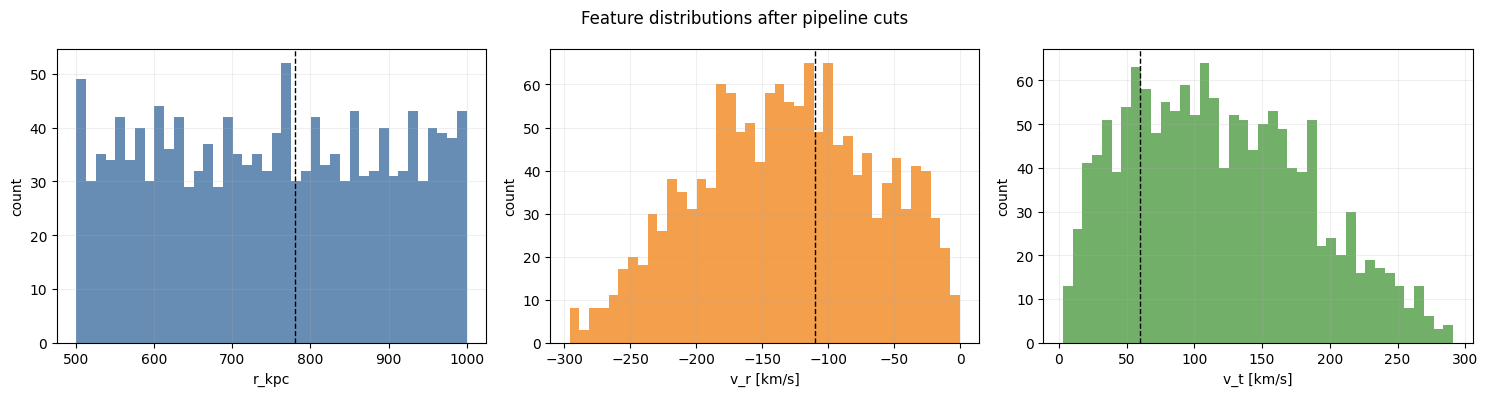

In [11]:
# Quick-look plots
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(cat["r_kpc"], bins=40, color="#4e79a7", alpha=0.85)
ax[0].axvline(x_obs[0], color="k", ls="--", lw=1)
ax[0].set_xlabel("r_kpc")

ax[1].hist(cat["v_r"], bins=40, color="#f28e2b", alpha=0.85)
ax[1].axvline(x_obs[1], color="k", ls="--", lw=1)
ax[1].set_xlabel("v_r [km/s]")

ax[2].hist(cat["v_t"], bins=40, color="#59a14f", alpha=0.85)
ax[2].axvline(x_obs[2], color="k", ls="--", lw=1)
ax[2].set_xlabel("v_t [km/s]")

for a in ax:
    a.set_ylabel("count")
    a.grid(alpha=0.2)

fig.suptitle("Feature distributions after pipeline cuts")
plt.tight_layout()
plt.show()


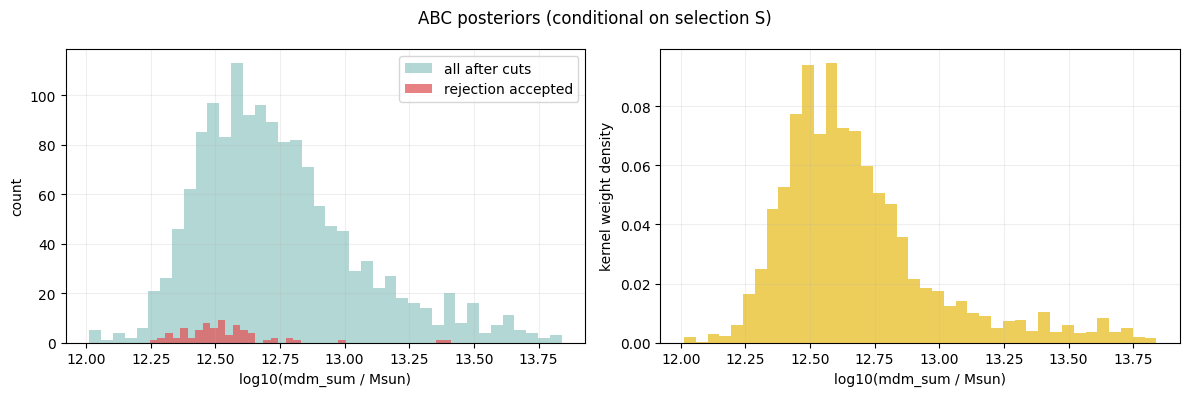

In [12]:
# Posterior visualization for theta = log10(mdm_sum)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(theta, bins=40, alpha=0.55, label="all after cuts", color="#76b7b2")
if theta_acc.size > 0:
    ax[0].hist(theta_acc, bins=40, alpha=0.75, label="rejection accepted", color="#e15759")
ax[0].set_xlabel("log10(mdm_sum / Msun)")
ax[0].set_ylabel("count")
ax[0].legend()
ax[0].grid(alpha=0.2)

ax[1].hist(theta, bins=40, weights=w, alpha=0.9, color="#edc948")
ax[1].set_xlabel("log10(mdm_sum / Msun)")
ax[1].set_ylabel("kernel weight density")
ax[1].grid(alpha=0.2)

fig.suptitle("ABC posteriors (conditional on selection S)")
plt.tight_layout()
plt.show()


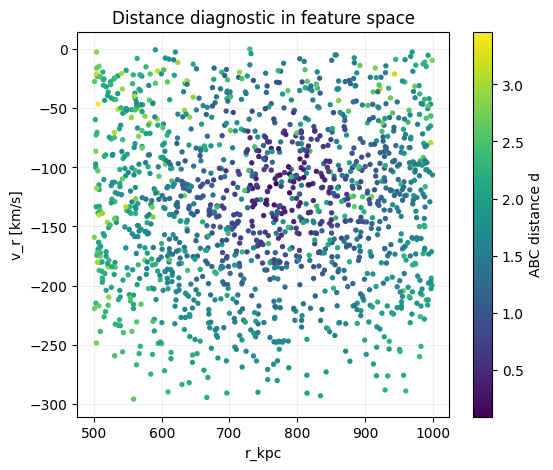

In [13]:
# Distance diagnostic: lower distance = closer to x_obs
plt.figure(figsize=(6, 5))
sc = plt.scatter(cat["r_kpc"], cat["v_r"], c=d, s=8, cmap="viridis")
plt.colorbar(sc, label="ABC distance d")
plt.xlabel("r_kpc")
plt.ylabel("v_r [km/s]")
plt.title("Distance diagnostic in feature space")
plt.grid(alpha=0.2)
plt.show()
